<a href="https://colab.research.google.com/github/ni1z3r0/serverless-bond-analyst/blob/test-rabbit/ENews_Express_Learner_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

## Import all the necessary libraries

In [8]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 94.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from google.colab import files
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error

from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/My Drive/Python Course/abtest.csv')



## Reading the Data into a DataFrame

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [47]:
df.head()



,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [26]:
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [51]:
print("the shape is",df.shape)
df['time_spent_on_the_page'].describe()

the shape is (100, 6)


,time_spent_on_the_page
count,100.000000
mean,5.377800
std,2.378166
min,0.190000
25%,3.880000
50%,5.415000
75%,7.022500
max,10.710000


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [57]:
# Check for missing values in each column
print(df.isnull().sum())

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


In [63]:
# Create a frequency table and force inclusion of both False and True
duplicate_table = df.duplicated().value_counts().reindex([False, True], fill_value=0).reset_index()

# Rename columns for the final display
duplicate_table.columns = ['Is Duplicate', 'Count']

print(duplicate_table)

# Specifically check if any user_id is repeated
print("\nnumber of user_id repeated",df['user_id'].duplicated().sum())

   Is Duplicate  Count
0         False    100
1          True      0

number of user_id repeated 0


### Univariate Analysis

In [54]:
from scipy.stats import shapiro

# Testing for normality
stats, p_value = shapiro(df['time_spent_on_the_page'])
print(f'Shapiro-Wilk Test: Statistics={stats:.3f}, p-value={p_value:.3f}')

# Logic: If p-value > 0.05, the data is normally distributed.

print('H0 = The data is normally distributed.') if p_value > 0.05 else print('H1 = The data is not normally distributed.')


Shapiro-Wilk Test: Statistics=0.989, p-value=0.564
H0 = The data is normally distributed.


In [55]:
# Frequency of categorical variables
print(df['group'].value_counts())
print(df['landing_page'].value_counts())
print(df['converted'].value_counts())
print(df['language_preferred'].value_counts())

group
control      50
treatment    50
Name: count, dtype: int64
landing_page
old    50
new    50
Name: count, dtype: int64
converted
yes    54
no     46
Name: count, dtype: int64
language_preferred
Spanish    34
French     34
English    32
Name: count, dtype: int64


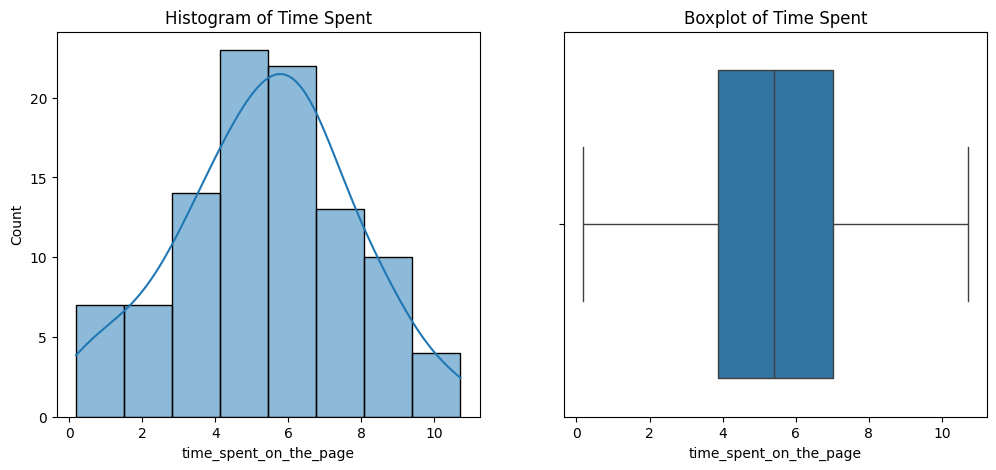

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the distribution of time spent
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['time_spent_on_the_page'], kde=True)
plt.title('Histogram of Time Spent')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['time_spent_on_the_page'])
plt.title('Boxplot of Time Spent')

plt.show()

# Univariate Data Analysis

In this section, we explore the individual variables in the dataset to understand their distributions, central tendencies, and identify any potential anomalies or patterns.

---

## 1. Numerical Variable: Time Spent on the Page
The variable `time_spent_on_the_page` represents the duration (in minutes) a user spends on the landing page.

**Descriptive Statistics:**
- **Mean:** $5.38$ minutes
- **Standard Deviation:** $2.38$ minutes
- **Minimum:** $0.19$ minutes
- **Maximum:** $10.71$ minutes
- **Median ($Q_2$):** $5.42$ minutes

**Observation:**
The mean and median are very close, which suggests that the distribution of time spent is approximately symmetric and follows a **Normal Distribution**. This is visually supported by the histogram and the Shapiro-Wilk test performed during data exploration.

---

## 2. Categorical Variables
We analyzed the frequency of the categorical variables to ensure the experiment was balanced and to understand user demographics.

### A. Group and Landing Page
- **Control Group / Old Page:** 50 users ($50\%$)
- **Treatment Group / New Page:** 50 users ($50\%$)
> **Observation:** The data is perfectly balanced, which is ideal for an A/B test.

### B. Conversion Status
- **Converted (Yes):** 54 users ($54\%$)
- **Not Converted (No):** 46 users ($46\%$)
> **Observation:** Slightly more than half of the sampled users converted to subscribers.

### C. Language Preference
- **Spanish:** 34 users
- **French:** 34 users
- **English:** 32 users
> **Observation:** The users are almost equally distributed among the three preferred languages.

---

## 3. Data Quality Check
Before proceeding to bivariate analysis, we confirmed the data quality.

| Check Type | Result |
| :--- | :--- |
| **Missing Values** | 0 |
| **Duplicate Rows** | 0 |
| **Unique Users** | 100 |

---

> **💡 Summary Insight:** The dataset is clean, balanced, and contains no missing or duplicate values. The primary metric (Time Spent) appears to be normally distributed, making it suitable for parametric statistical testing (like T-tests and ANOVA).

### Bivariate Analysis

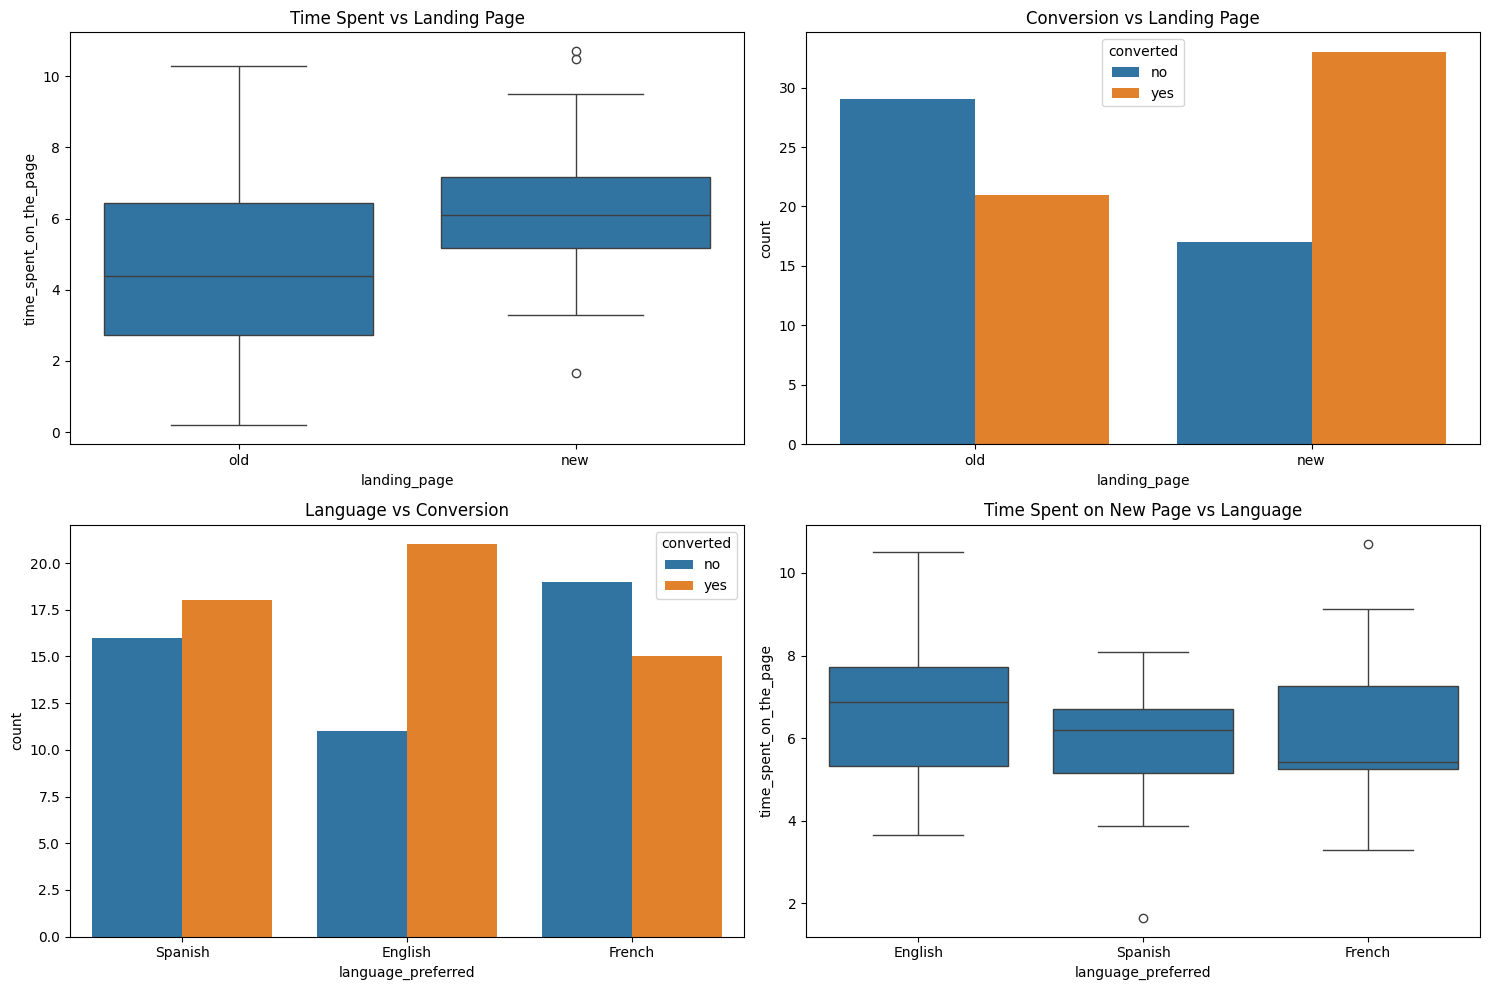

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# 1. Continuous vs Discrete: Time Spent vs Landing Page
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent vs Landing Page')

# 2. Discrete vs Discrete: Conversion vs Landing Page
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='landing_page', hue='converted')
plt.title('Conversion vs Landing Page')

# 3. Discrete vs Discrete: Language vs Conversion
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='language_preferred', hue='converted')
plt.title('Language vs Conversion')

# 4. Continuous vs Discrete: Time Spent vs Language (for the New Page)
plt.subplot(2, 2, 4)
sns.boxplot(data=df[df['landing_page']=='new'], x='language_preferred', y='time_spent_on_the_page')
plt.title('Time Spent on New Page vs Language')

plt.tight_layout()
plt.show()

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

Text(0.5, 1.0, 'Time Spent vs Landing Page')

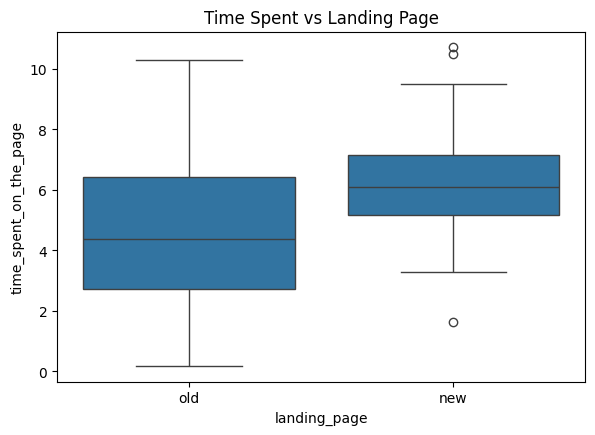

In [71]:
plt.figure(figsize=(15, 10))

# 1. Continuous vs Discrete: Time Spent vs Landing Page
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent vs Landing Page')

### Step 1: Define the null and alternate hypotheses

### Hypothesis Testing
- $H_0: \mu_{new} = \mu_{old}$
- $H_a: \mu_{new} > \mu_{old}$
- **Significance Level ($\alpha$):** 0.05

### Step 2: Select Appropriate test

**Univariate**
We are analyzing one variable, the mean of two independent groups.

**Continuous and Normal**
Shapiro test confirms this is Normal

**We are looking at two samples, new sample vs old sample**
This is a test comparing means with uknown variance
Use ttest_ind

### Step 3: Decide the significance level

Objective is to test at significance level of 5% per question.

### Step 4: Collect and prepare data

In [73]:
from scipy.stats import ttest_ind

# Filter rows where landing_page is 'new'
time_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']

# Filter rows where landing_page is 'old'
time_old = df[df['landing_page'] == 'old']['time_spent_on_the_page']



### Step 5: Calculate the p-value

In [75]:
from scipy import stats

t_stat, p_val= stats.ttest_ind(time_new,time_old,equal_var=True,alternative="greater")

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 3.7867702694199856
P-value: 0.0001316123528095005


### Step 6: Compare the p-value with $\alpha$

In [77]:
print(f"P-value: {p_val} is less than .05")

P-value: 0.0001316123528095005 is less than .05


### Step 7:  Draw inference

We reject the null hypothesis and conclude users do spend more time on the new page.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

## 3. Is the conversion and preferred language are independent or related?

## 4. Is the time spent on the new page same for the different language users?

## Conclusion and Business Recommendations

___